# 25 — L'effet de page, une fois la composition retirée

Le [chapitre précédent](../format-et-retour.md) a mesuré qu'un format enrichi servi plus haut
retire **8,4 points** d'examen à ce qui suit, à rang et à hauteur de page comparables, et en a
tiré une conclusion large : la remise d'attention $w_R$ ne serait pas une propriété du rang mais
de la **page servie**, et aucune loi $e(R)$ ne pourrait la représenter.

Ce chapitre reprend la même mesure avec un contrôle que le précédent n'avait pas : **le contenu**.

Comparer les pages enrichies aux autres, même à rang égal, c'est comparer deux populations de
requêtes. Un encadré de réponse ne s'affiche pas au hasard : il répond à une question factuelle,
qui n'appelle pas la même lecture qu'une recherche exploratoire. L'écart mesuré peut donc venir
du format, ou de *ce sur quoi* le format apparaît.

La question de ce chapitre est celle-là, et une seule : **quelle part de l'effet publié est un
effet, et quelle part est une composition ?**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.entropy import label_diversity_index
from ide.exposure import load_digest, page_effect_counts, page_examination_curve
from ide.logs import Impressions, count_above, stratified_risk_ratio
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()
DEPTH = 9  # au-delà, Baidu-ULTR ne sert plus qu'une poignée d'impressions par rang

# Le journal brut n'est pas versionné : le condensé porte les comptes appariés, et rend les
# mêmes chiffres que la lecture directe du fichier — deux tests le vérifient.
digest = load_digest()
curve = page_examination_curve(digest)
exposures = curve["exposures"].reshape(-1, 5).astype(float)
seen = curve["seen"].reshape(-1, 5).astype(float)
ranks = np.arange(1, exposures.shape[0] + 1)

print("e(R | nombre de formats enrichis servis plus haut)\n")
print("rang " + "".join(f"{n:>9}" for n in range(5)))
for rank in range(DEPTH):
    line = "".join(f"{seen[rank, n] / exposures[rank, n]:>9.3f}"
                   if exposures[rank, n] > 500 else f"{'.':>9}" for n in range(5))
    print(f"{ranks[rank]:>4}" + line)

e(R | nombre de formats enrichis servis plus haut)

rang         0        1        2        3        4
   1    0.984        .        .        .        .
   2    0.913    0.833        .        .        .
   3    0.722    0.606    0.590        .        .
   4    0.507    0.415    0.405    0.446        .
   5    0.372    0.302    0.267    0.312    0.341
   6    0.323    0.270    0.227    0.219    0.259
   7    0.290    0.240    0.199    0.187    0.205
   8    0.277    0.218    0.175    0.172    0.174
   9    0.251    0.195    0.156    0.151    0.149


## 1. Ce que dit le contraste brut

Trois façons de lire le même tableau, de la plus naïve à la plus prudente. Aucune des trois ne
tient encore le contenu fixe.

In [2]:
shallow = (ranks >= 2) & (ranks <= DEPTH)
untreated, treated = exposures[:, 0], exposures[:, 1:].sum(1)
untreated_seen, treated_seen = seen[:, 0], seen[:, 1:].sum(1)

brut = ((treated_seen[shallow].sum() / treated[shallow].sum())
        / (untreated_seen[shallow].sum() / untreated[shallow].sum()))
par_rang = stratified_risk_ratio(untreated[shallow], treated[shallow],
                                 untreated_seen[shallow], treated_seen[shallow])

print(f"contraste brut, rangs 2 à {DEPTH}          RR = {brut:.3f}")
print(f"stratifié par rang                  RR = {par_rang.ratio:.3f}  "
      f"IC95 = [{par_rang.low:.3f}, {par_rang.high:.3f}]  "
      f"({par_rang.impressions:,} impressions)".replace(",", " "))
print("\nC'est ce second chiffre que le chapitre précédent publiait : dix-huit points relatifs,")
print("soit les huit points d'examen perdus sur une base de 0,45.")

contraste brut, rangs 2 à 9          RR = 0.613
stratifié par rang                  RR = 0.817  IC95 = [0.812  0.823]  (452 689 impressions)

C'est ce second chiffre que le chapitre précédent publiait : dix-huit points relatifs,
soit les huit points d'examen perdus sur une base de 0,45.


## 2. Le contrôle qui décide de la suite

Règle du dépôt, acquise trois fois à ses dépens : **appliquer d'abord le protocole à des données
dont on connaît la réponse.**

On simule ici un monde où le format n'a *aucun* effet sur l'examen, mais où les pages enrichies
tombent sur des contenus systématiquement moins consultés — exactement le confondant soupçonné.
Un estimateur qui prétend mesurer l'effet du format doit rendre 1.

On simule ensuite un monde où le format a un effet **connu** de $0{,}90$. Le même estimateur doit
le retrouver.

In [3]:
CATALOGUE, FEEDS, SLOTS = 300, 120_000, DEPTH


def monde_simule(effet, rng, severity=0.9):
    # Un journal où l'attribution du format dépend de la qualité des contenus servis.
    quality = np.clip(rng.lognormal(-0.9, 0.5, CATALOGUE), 0.02, 1.0)
    items = rng.integers(0, CATALOGUE, size=(FEEDS, SLOTS))
    rank_grid = np.tile(np.arange(1, SLOTS + 1), (FEEDS, 1))

    # Le format enrichi tombe sur les fils dont les contenus sont les moins consultés : la
    # composition, à elle seule, suffit à creuser un écart.
    enrichi = quality[items].mean(1) < np.quantile(quality[items].mean(1), 0.5)
    au_dessus = np.where(enrichi[:, None] & (rank_grid >= 2), 1, 0)

    probability = np.clip(quality[items] * rank_grid ** -severity, 0.0, 1.0)
    probability = np.where(au_dessus > 0, probability * effet, probability)
    examine = (rng.random((FEEDS, SLOTS)) < probability).astype(float)

    journal = Impressions(items=items.ravel(), ranks=rank_grid.ravel(),
                          clicks=np.zeros(FEEDS * SLOTS),
                          feeds=np.repeat(np.arange(FEEDS), SLOTS),
                          feed_lengths=np.full(FEEDS, SLOTS))
    return journal, examine.ravel(), au_dessus.ravel()


def apparie(journal, examine, traite, garde):
    # Le rapport de risques, à contenu et rang fixés — le même code que sur données réelles.
    strata = np.stack([journal.items[garde], journal.ranks[garde]], axis=1)
    keys, index = np.unique(strata, axis=0, return_inverse=True)
    slots = index * 2 + traite[garde]
    counts = np.bincount(slots, minlength=2 * len(keys)).reshape(-1, 2).astype(float)
    hits = np.bincount(slots, weights=examine[garde], minlength=2 * len(keys)).reshape(-1, 2)
    return stratified_risk_ratio(counts[:, 0], counts[:, 1], hits[:, 0], hits[:, 1])


generator = np.random.default_rng(20260823)
print("effet simulé   RR stratifié par rang   RR à contenu fixé")
for effet in (1.0, 0.90):
    journal, examine, au_dessus = monde_simule(effet, generator)
    garde = journal.ranks >= 2
    traite = (au_dessus > 0).astype(np.int64)

    par_rang_simule = stratified_risk_ratio(
        *[np.bincount(journal.ranks[garde], weights=poids)[2:]
          for poids in ((traite[garde] == 0), (traite[garde] == 1),
                        examine[garde] * (traite[garde] == 0),
                        examine[garde] * (traite[garde] == 1))])
    mesure = apparie(journal, examine, traite, garde)
    print(f"    {effet:.2f}              {par_rang_simule.ratio:.3f}                "
          f"{mesure.ratio:.3f}  IC95 = [{mesure.low:.3f}, {mesure.high:.3f}]")

effet simulé   RR stratifié par rang   RR à contenu fixé


    1.00              0.785                1.005  IC95 = [0.993, 1.016]


    0.90              0.701                0.896  IC95 = [0.886, 0.907]


Le protocole passe les deux épreuves : il ne voit rien là où il n'y a rien, et retrouve l'effet
là où il est. La stratification par le rang seul, elle, échoue à la première — elle lit un effet
franc dans un monde qui n'en porte aucun.

C'est précisément la lecture que le chapitre précédent avait faite.

## 3. La mesure, à contenu fixé puis à requête fixée

Deux appariements indépendants. Le premier compare **le même document au même rang**, servi une
fois avec un format enrichi au-dessus et une fois sans. Le second compare **la même requête au
même rang**. Ils ne partagent ni leurs strates ni leurs impressions ; ils doivent néanmoins
rendre le même chiffre.

In [4]:
def rapport(stratification, borne=DEPTH):
    counts = page_effect_counts(digest, stratification)
    kept = (counts["ranks"] >= 2) & (counts["ranks"] <= borne)
    return stratified_risk_ratio(counts["untreated"][kept], counts["treated"][kept],
                                 counts["untreated_seen"][kept], counts["treated_seen"][kept])


par_contenu, par_requete = rapport("document"), rapport("query")
for nom, mesure in (("même document, même rang", par_contenu),
                    ("même requête, même rang", par_requete)):
    print(f"{nom:<26} RR = {mesure.ratio:.3f}  IC95 = [{mesure.low:.3f}, {mesure.high:.3f}]  "
          f"{mesure.strata:>5} strates, {mesure.impressions:>7,} impressions".replace(",", " "))

print("\nrang   strates          RR      IC95")
counts = page_effect_counts(digest, "document")
par_rang_apparie = {}
for rank in range(2, DEPTH + 1):
    cell = counts["ranks"] == rank
    mesure = stratified_risk_ratio(counts["untreated"][cell], counts["treated"][cell],
                                   counts["untreated_seen"][cell], counts["treated_seen"][cell])
    par_rang_apparie[rank] = mesure
    print(f"{rank:>4}   {mesure.strata:>7}   {mesure.ratio:>9.3f}   "
          f"[{mesure.low:.3f}, {mesure.high:.3f}]")

même document  même rang   RR = 0.940  IC95 = [0.916  0.964]   1106 strates   31 045 impressions
même requête  même rang    RR = 0.942  IC95 = [0.869  1.022]    880 strates    4 261 impressions

rang   strates          RR      IC95
   2       163       0.983   [0.947, 1.020]
   3       163       0.964   [0.938, 0.990]
   4       152       0.822   [0.740, 0.914]
   5       140       0.851   [0.745, 0.973]
   6       138       0.860   [0.689, 1.073]
   7       130       0.977   [0.842, 1.134]
   8       109       0.949   [0.635, 1.419]
   9       111       1.203   [0.735, 1.970]


**Les deux tiers de l'effet publié étaient de la composition.** Dix-huit points relatifs
deviennent six, et les deux appariements concordent à deux millièmes près alors que l'un repose
sur sept fois plus d'impressions que l'autre.

Ce qui reste est **établi** par l'appariement le plus peuplé — l'intervalle exclut 1 — et ne
l'est pas par l'autre, trop peu peuplé pour trancher seul. Rang par rang, aucune tendance ne se
dégage : l'effet ne se creuse pas avec la profondeur, et l'hypothèse la plus simple qui reste est
celle d'un **facteur constant**.

## 4. Ce que coûte, en pratique, d'ignorer la page

La conclusion du chapitre précédent — « aucune loi $e(R)$ ne peut représenter cela » — se teste
en la chiffrant. Deux écarts, sur les mêmes fils simulés :

* celui qu'on commet en employant la remise **marginale** mesurée là où la page est enrichie ;
* celui qu'on commet en employant la **convention $1/R$**, qui est ce que fait la littérature — et
  ce que faisait ce dépôt jusqu'au chapitre 23.

In [5]:
part_enrichie = (exposures[:, 1:].sum(1) / exposures.sum(1))[:DEPTH]
marginale = (seen.sum(1) / exposures.sum(1))[:DEPTH]

# La remise que verrait un régulateur mesurant sans distinguer les pages, contre les deux
# compositions extrêmes : une page entièrement nue, une page enrichie dès le premier rang. Le
# rang 1 ne porte jamais rien au-dessus de lui : c'est par lui que l'effet cesse d'être une
# simple homothétie, à laquelle un indice normalisé serait insensible.
nue = marginale / (1 - part_enrichie + part_enrichie * par_contenu.ratio)
enrichie = nue.copy()
enrichie[1:] *= par_contenu.ratio
convention = np.arange(1, DEPTH + 1, dtype=float) ** -1.0


def indice_expose(poids, etiquettes, catalogue=4):
    # L'IDE d'un fil : l'entropie des points de vue servis, pondérée par l'attention.
    servi = np.array([poids[etiquettes == vue].sum() for vue in range(catalogue)])
    parts = np.round(servi / servi.sum() * 10_000).astype(int)
    return label_diversity_index(np.repeat(np.arange(catalogue), parts),
                                 catalogue_size=catalogue)


generator = np.random.default_rng(20260823)
ecart_page, ecart_convention = [], []
for _ in range(4_000):
    etiquettes = generator.integers(0, 4, size=DEPTH)
    reference = indice_expose(marginale, etiquettes)
    ecart_page.append(max(abs(reference - indice_expose(enrichie, etiquettes)),
                          abs(reference - indice_expose(nue, etiquettes))))
    ecart_convention.append(abs(reference - indice_expose(convention, etiquettes)))
ecart_page, ecart_convention = np.array(ecart_page), np.array(ecart_convention)

print(f"écart d'indice, page ignorée      médian {np.median(ecart_page):.4f}   "
      f"99e centile {np.quantile(ecart_page, 0.99):.4f}")
print(f"écart d'indice, convention 1/R    médian {np.median(ecart_convention):.4f}   "
      f"99e centile {np.quantile(ecart_convention, 0.99):.4f}")
print(f"\nrapport des deux : {np.median(ecart_convention) / np.median(ecart_page):.0f} fois")


def severite(taux):
    pente, _ = np.polyfit(np.log(np.arange(1, DEPTH + 1)), np.log(taux), 1)
    return -pente


print(f"\nsévérité mesurée en ignorant la page      η = {severite(marginale):.3f}")
print(f"sévérité sur la page contrefactuelle nue  η = {severite(nue):.3f}")

écart d'indice, page ignorée      médian 0.0025   99e centile 0.0066
écart d'indice, convention 1/R    médian 0.0350   99e centile 0.0735

rapport des deux : 14 fois

sévérité mesurée en ignorant la page      η = 0.876
sévérité sur la page contrefactuelle nue  η = 0.854


## 5. La figure

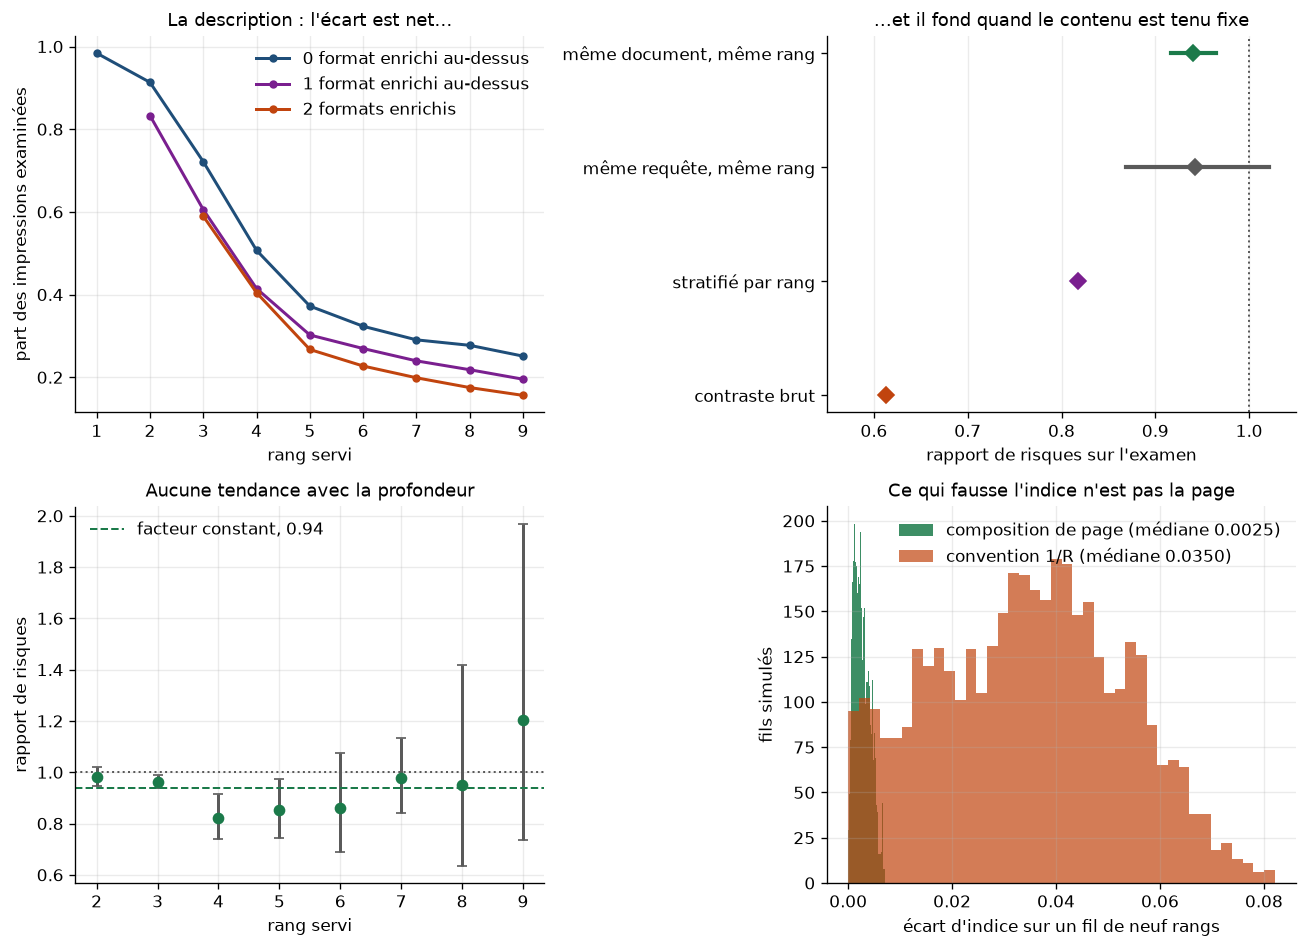

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
for n in range(3):
    lisible = exposures[:DEPTH, n] > 500
    taux = np.divide(seen[:DEPTH, n], exposures[:DEPTH, n],
                     out=np.zeros(DEPTH), where=exposures[:DEPTH, n] > 0)
    ax.plot(ranks[:DEPTH][lisible], taux[lisible],
            marker="o", markersize=4,
            color=[PALETTE["order"], PALETTE["field"], PALETTE["disorder"]][n],
            label=f"{n} format enrichi au-dessus" if n < 2 else f"{n} formats enrichis")
ax.set(xlabel="rang servi", ylabel="part des impressions examinées",
       title="La description : l'écart est net…")
ax.legend()

ax = axes[0, 1]
lectures = [("contraste brut", brut, None, None, PALETTE["disorder"]),
            ("stratifié par rang", par_rang.ratio, par_rang.low, par_rang.high, PALETTE["field"]),
            ("même requête, même rang", par_requete.ratio, par_requete.low, par_requete.high,
             PALETTE["neutral"]),
            ("même document, même rang", par_contenu.ratio, par_contenu.low, par_contenu.high,
             PALETTE["remedy"])]
for position, (nom, valeur, bas, haut, couleur) in enumerate(lectures):
    if bas is not None:
        ax.plot([bas, haut], [position, position], color=couleur, linewidth=2.5)
    ax.plot([valeur], [position], marker="D", markersize=7, color=couleur)
ax.axvline(1.0, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.set(yticks=range(len(lectures)), yticklabels=[nom for nom, *_ in lectures],
       xlabel="rapport de risques sur l'examen", xlim=(0.55, 1.05),
       title="…et il fond quand le contenu est tenu fixe")
ax.grid(axis="y", alpha=0.0)

ax = axes[1, 0]
positions = sorted(par_rang_apparie)
valeurs = [par_rang_apparie[rank].ratio for rank in positions]
ax.errorbar(positions, valeurs,
            yerr=[[v - par_rang_apparie[r].low for v, r in zip(valeurs, positions, strict=True)],
                  [par_rang_apparie[r].high - v for v, r in zip(valeurs, positions, strict=True)]],
            fmt="o", color=PALETTE["remedy"], ecolor=PALETTE["neutral"], capsize=3)
ax.axhline(1.0, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.axhline(par_contenu.ratio, color=PALETTE["remedy"], linestyle="--", linewidth=1.2,
           label=f"facteur constant, {par_contenu.ratio:.2f}")
ax.set(xlabel="rang servi", ylabel="rapport de risques",
       title="Aucune tendance avec la profondeur")
ax.legend()

ax = axes[1, 1]
ax.hist(ecart_page, bins=40, color=PALETTE["remedy"], alpha=0.85,
        label=f"composition de page (médiane {np.median(ecart_page):.4f})")
ax.hist(ecart_convention, bins=40, color=PALETTE["disorder"], alpha=0.7,
        label=f"convention 1/R (médiane {np.median(ecart_convention):.4f})")
ax.set(xlabel="écart d'indice sur un fil de neuf rangs", ylabel="fils simulés",
       title="Ce qui fausse l'indice n'est pas la page")
ax.legend()

save_figure(figure, "fig25_effet_de_page.png")
plt.show()

## 6. Ce que ce chapitre change

**Une conclusion publiée par ce dépôt est corrigée d'un facteur trois.** L'effet du format sur
l'examen n'est pas de dix-huit points relatifs mais de **six**, et les deux tiers de ce qui était
publié tenaient à *quelles* requêtes déclenchent un encadré de réponse. L'erreur était de celles
que ce dépôt a déjà rencontrées cinq fois : un chiffre du bon signe, du bon ordre de grandeur, et
faux par ce qu'on n'avait pas tenu fixe.

**L'affirmation la plus large du chapitre précédent tombe.** « Aucune loi $e(R)$ ne peut
représenter cela » supposait un effet de page assez fort pour interdire une loi de rang. Une fois
chiffré, il déplace l'indice de $0{,}002$ là où la convention $1/R$ le déplace de $0{,}036$ :
**quinze fois moins**. La loi de rang tient, et ce qui la menace n'est pas la page — c'est de ne
pas l'avoir mesurée.

**Et l'ordre des priorités s'inverse.** Ce qu'un régulateur doit exiger d'abord n'est pas le
format servi, mais la **mesure de l'exposition elle-même**. La colonne `format` de la
demande d'accès reste utile — elle permet de vérifier ce chapitre sur une
autre plateforme — mais elle cesse d'être nécessaire au calcul de l'indice.

**Réserves.** L'appariement à contenu fixé ne retient que $1\,106$ strates sur $404\,478$ : ce
sont les documents servis au même rang dans des pages de compositions différentes, et rien ne
garantit qu'ils ressemblent aux autres. L'appariement par requête, indépendant, concorde — mais
il est sept fois moins peuplé et n'établit rien seul. Enfin, le regroupement de `media_type` en
« ordinaire » contre « enrichi » reste un choix de ce dépôt.